In [40]:
import os
import time
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from collections import Counter

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim

In [41]:
# 기본 설정
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)

INPUT_DIR = r"kaggle\input\competitions\010881-001-2-cub-200-2011"

CSV_PATH = os.path.join(INPUT_DIR, "train_labels.csv")
TEST_CSV_PATH = os.path.join(INPUT_DIR, "test.csv")
SAMPLE_SUBMISSION_PATH = os.path.join(INPUT_DIR, "sample_submission.csv")

OUTPUT_DIR = r"kaggle\working"

CHECKPOINT_DIR = "./checkpoints"

IMAGE_SIZE = 224

device: cuda:0


In [42]:
# Transform 정의
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.7, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [43]:
# dataset 정의
class CustomDataset(Dataset):
    def __init__(self, df, input_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.input_dir = input_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        image_path = os.path.join(self.input_dir, row["image_path"])
        label = int(row["label"])
         
        image = Image.open(image_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        label = torch.tensor(label, dtype=torch.long)
        
        return image, label
    
class CustomDatasetTest(Dataset):
    def __init__(self, df, input_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.input_dir = input_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        image_path = os.path.join(self.input_dir, row["image_path"])
        image = Image.open(image_path).convert("RGB")
        
        if self.transform is not None:
            image = self.transform(image)
            
        image_id = row["id"]
        
        return image, image_id

In [44]:
# DataLoader 생성 함수
def make_dataloaders(
    csv_path,
    input_dir,
    batch_size=32,
    split_seed=42,
    num_workers=0
):
    df = pd.read_csv(csv_path)
    
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=split_seed,
        stratify=df["label"]
    )
    
    train_dataset = CustomDataset(
        df=train_df,
        input_dir=input_dir,
        transform=train_transform
    )
    
    val_dataset = CustomDataset(
        df=val_df,
        input_dir=input_dir,
        transform=val_transform
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    print("train size:", len(train_dataset))
    print("val size:", len(val_dataset))

    return train_loader, val_loader, train_df, val_df

In [45]:
class CNN(nn.Module):
    def __init__(self, num_classes=200):
        super(CNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.4),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [46]:
# 모델 선택 함수 (추후 앙상블 확장에 이용)
def build_model(model_name="CNN", num_classes=200):
    if model_name == "CNN":
        return CNN(num_classes=num_classes)
    
    raise ValueError(f"찾는 모델의 이름이 없습니다 : {model_name}")

In [47]:
# Optimier / Scheduler 생성 함수
def build_optimizer(model, lr=1e-3, weight_decay=1e-4):
    return optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    
def build_scheduler(optimizer, num_epochs):
    return optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs
    )

In [48]:
# 학습 함수
def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch=None, num_epochs=None):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    if epoch is not None and num_epochs is not None:
        desc = f"Train [{epoch}/{num_epochs}]"
    else:
        desc = "Training"

    progress_bar = tqdm(
        train_loader,
        desc=desc,
        leave=False
    )
    
    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        batch_size = images.size(0)

        running_loss += loss.item() * batch_size
        
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        current_loss = running_loss / total
        current_acc = correct / total

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_acc:.4f}"
        })
        
    return running_loss / total, correct / total

In [49]:
# 검증 함수
def validate(model, val_loader, criterion, device, epoch=None, num_epochs=None):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0

    if epoch is not None and num_epochs is not None:
        desc = f"Val   [{epoch}/{num_epochs}]"
    else:
        desc = "Validation"

    progress_bar = tqdm(
        val_loader,
        desc=desc,
        leave=False
    )
    
    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            batch_size = images.size(0)

            running_loss += loss.item() * batch_size
            
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            current_loss = running_loss / total
            current_acc = correct / total

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })
    
    return running_loss / total, correct / total

In [50]:
# 추론 함수 (class와 softmax 확률값 반환)
def predict_with_model(
    model,
    test_loader,
    device
):
    model.eval()
    
    image_ids = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, ids in tqdm(test_loader, desc="Inference", leave=False):
            images = images.to(device)
            
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)
            
            image_ids.extend(list(ids))
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy())
            
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    
    return image_ids, all_preds, all_probs

In [51]:
# 다수결 voting 함수

def majority_vote_with_prob_tiebreak(
    pred_list,
    prob_list
):
    """
    pred_list: [model1_preds, model2_preds, ...]
        각 원소 shape: (num_samples,)
        
    prob_list: [model1_probs, model2_probs, ...]
        각 원소 shape: (num_samples, num_classes)
        
    return:
        final_preds shape: (num_samples,)
    """
    
    pred_array = np.stack(pred_list, axis=0)
    prob_array = np.stack(prob_list, axis=0)
    
    # shape: (num_models, num_samples)
    num_models, num_samples = pred_array.shape
    
    # 모델들의 평균 확률
    mean_probs = prob_array.mean(axis=0)
    
    final_preds = []
    
    for i in range(num_samples):
        votes = pred_array[:, i]
        counter = Counter(votes)
        
        max_vote_count = max(counter.values())
        candidates = [
            cls for cls, count in counter.items()
            if count == max_vote_count
        ]
        
        if len(candidates) == 1:
            final_pred = candidates[0]
        else:
            # 동률이면 평균 softmax 확률이 가장 높은 class 선택
            candidate_probs = {
                cls: mean_probs[i, cls]
                for cls in candidates
            }
            final_pred = max(candidate_probs, key=candidate_probs.get)
        
        final_preds.append(final_pred)
    
    return np.array(final_preds)
    

In [52]:
# 조기종료 관리 클래스
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = float("inf")
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return True

        self.counter += 1

        if self.counter >= self.patience:
            self.early_stop = True

        return False

In [53]:
# 학습 그래프 그리는 함수
def plot_history(history, title="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train / Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Train / Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()
    

In [54]:
# 단일 모델 학습 함수

def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    num_epochs=50,
    patience=10,
    min_delta=0.001,
    save_path="./checkpoints/best_model.pth",
    plot=True,
    title="Model"
):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    early_stopping = EarlyStopping(
        patience=patience,
        min_delta=min_delta
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": []
    }

    best_val_loss = float("inf")
    best_val_acc = 0.0

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            epoch=epoch + 1,
            num_epochs=num_epochs
        )

        val_loss, val_acc = validate(
            model=model,
            val_loader=val_loader,
            criterion=criterion,
            device=device,
            epoch=epoch + 1,
            num_epochs=num_epochs
        )

        if scheduler is not None:
            scheduler.step()
            current_lr = scheduler.get_last_lr()[0]
        else:
            current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} "
            f"LR: {current_lr:.6f}"
        )

        improved = early_stopping(val_loss)

        if improved:
            best_val_loss = val_loss
            best_val_acc = val_acc

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "best_val_loss": best_val_loss,
                    "best_val_acc": best_val_acc,
                    "history": history
                },
                save_path
            )

            print(
                f"Best model saved | "
                f"Val Loss: {best_val_loss:.4f} | "
                f"Val Acc: {best_val_acc:.4f}"
            )

        if early_stopping.early_stop:
            print(
                f"Early stopping at epoch {epoch+1} | "
                f"Best Val Loss: {best_val_loss:.4f} | "
                f"Best Val Acc: {best_val_acc:.4f}"
            )
            break

    end_time = time.time()
    total_time = end_time - start_time

    h = int(total_time // 3600)
    m = int((total_time % 3600) // 60)
    s = int(total_time % 60)

    print("=" * 70)
    print(f"{title} training finished")
    print(f"Total training time: {h}h {m}m {s}s")
    print(f"Best Val Loss: {best_val_loss:.4f}")
    print(f"Best Val Acc: {best_val_acc:.4f}")
    print("=" * 70)

    if plot:
        plot_history(history, title=title)

    return history, best_val_loss, best_val_acc

In [55]:
# Seed 고정 함수
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [56]:
# Seed 별 단일 모델 학습 함수

def train_single_model_from_config(
    config,
    csv_path,
    input_dir,
    device
):
    seed = config["seed"]
    model_name = config["model_name"]
    num_classes = config.get("num_classes", 200)
    num_epochs = config.get("num_epochs", 50)
    lr = config.get("lr", 1e-3)
    weight_decay = config.get("weight_decay", 1e-4)
    patience = config.get("patience", 10)
    min_delta = config.get("min_delta", 0.001)
    batch_size = config.get("batch_size", 32)
    split_seed = config.get("split_seed", 42)
    num_workers = config.get("num_workers", 2)
    save_dir = config.get("save_dir", "./checkpoints")
    plot = config.get("plot", False)
    modelfile_save_name = config.get("modelfile_save_name", f"{model_name}_seed{seed}")

    print("\n" + "#" * 80)
    print(f"Training model: {model_name} | seed: {seed}")
    print(f"lr={lr} | weight_decay={weight_decay} | epochs={num_epochs}")
    print("#" * 80)

    set_seed(seed)
    
    train_loader, val_loader, train_df, val_df = make_dataloaders(
        csv_path=csv_path,
        input_dir=input_dir,
        batch_size=batch_size,
        split_seed=split_seed,
        num_workers=num_workers
    )

    model = build_model(
        model_name=model_name,
        num_classes=num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = build_optimizer(
        model=model,
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = build_scheduler(
        optimizer=optimizer,
        num_epochs=num_epochs
    )

    save_path = os.path.join(
        save_dir,
        modelfile_save_name
    )

    history, best_val_loss, best_val_acc = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=num_epochs,
        patience=patience,
        min_delta=min_delta,
        save_path=save_path,
        plot=plot,
        title=f"{model_name}_seed{seed}"
    )

    result = {
        "seed": seed,
        "model_name": model_name,
        "save_path": save_path,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
        "history": history,
        "config": config
    }

    return result


################################################################################
Training model: CNN | seed: 100
lr=0.001 | weight_decay=0.0001 | epochs=1
################################################################################
train size: 7544
val size: 1886


Epoch [1/1] Train Loss: 5.1779 | Train Acc: 0.0135 Val Loss: 4.9943 | Val Acc: 0.0159 LR: 0.000000
Best model saved | Val Loss: 4.9943 | Val Acc: 0.0159
CNN_seed100 training finished
Total training time: 0h 0m 48s
Best Val Loss: 4.9943
Best Val Acc: 0.0159


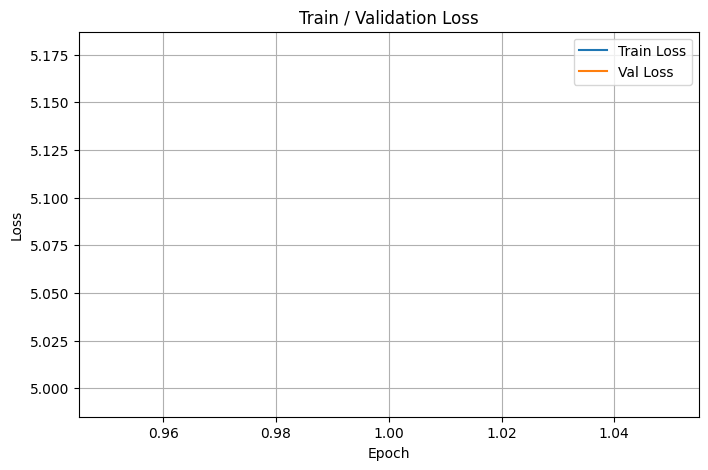

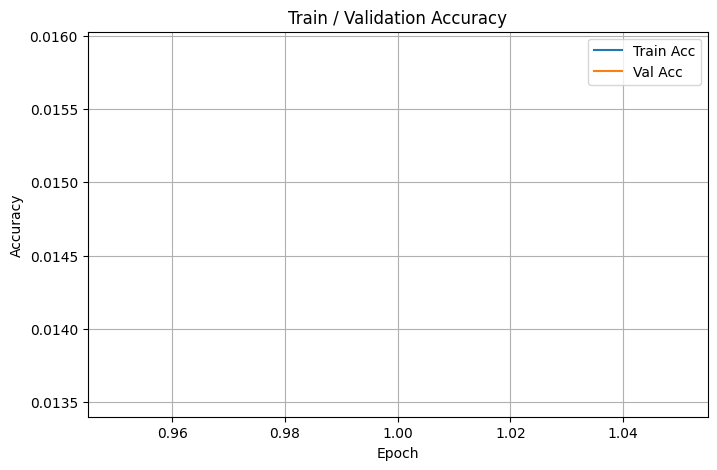


앙상블 모델 학습 완료 
, 총 학습 시간 : 0h 0m 48s


In [57]:
# 앙상블 학습 실행

ensemble_configs = [
    {
        "seed": 100,
        "model_name": "CNN",
        "num_classes": 200,
        "num_epochs": 1,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "patience": 10,
        "min_delta": 0.001,
        "batch_size": 32,
        "split_seed": 42,
        "num_workers": 0,
        "save_dir": CHECKPOINT_DIR,
        "plot": True,
        "modelfile_save_name": "base_model.pth"
    }
]

ensemble_results = []

total_start_time = time.time()

for config in ensemble_configs:
    result = train_single_model_from_config(
        config=config,
        csv_path=CSV_PATH,
        input_dir=INPUT_DIR,
        device=device
    )
    
    ensemble_results.append(result)
    
total_end_time = time.time()
total_time = total_end_time - total_start_time

h = int(total_time // 3600)
m = int((total_time % 3600) // 60)
s = int(total_time % 60)

print("\n" + "=" * 80)
print("앙상블 모델 학습 완료 ")
print(f", 총 학습 시간 : {h}h {m}m {s}s")
print("=" * 80)



In [59]:
# 앙상블 추론후 submission 생성

MODEL_PATHS = [
    {
        "pth": os.path.join(CHECKPOINT_DIR, "base_model.pth"),
        "model": "CNN"
    },
    {
        "pth": os.path.join(CHECKPOINT_DIR, "CNN_seed100.pth"),
        "model": "CNN"
    }
]

test_df = pd.read_csv(TEST_CSV_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

test_dataset = CustomDatasetTest(
    df=test_df,
    input_dir=INPUT_DIR,
    transform=val_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

ensemble_preds = []
ensemble_probs = []
image_ids = None

for model_idx, model_path in enumerate(MODEL_PATHS):
    print("\n" + "=" * 80)
    print(f"Load model {model_idx + 1}/{len(MODEL_PATHS)}")
    print("path:", model_path["pth"])
    print("=" * 80)
    
    model = build_model(
        model_name=model_path["model"],
        num_classes=200
    ).to(device)
    
    checkpoint = torch.load(model_path["pth"], map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    
    current_image_ids, preds, probs = predict_with_model(
        model=model,
        test_loader=test_loader,
        device=device
    )
    
    if image_ids is None:
        image_ids = current_image_ids
    else:
        assert image_ids == current_image_ids, "모델별 image_id 순서가 다릅니다."
    
    ensemble_preds.append(preds)
    ensemble_probs.append(probs)
    
    del model
    torch.cuda.empty_cache()

final_predictions = majority_vote_with_prob_tiebreak(
    pred_list=ensemble_preds,
    prob_list=ensemble_probs
)

pred_df = pd.DataFrame({
    "id": image_ids,
    "label": final_predictions
})

submission = sample_submission[["id"]].merge(
    pred_df,
    on="id",
    how="left"
)

missing_count = submission["label"].isna().sum()
print("missing predictions:", missing_count)

if missing_count > 0:
    raise ValueError("일부 test sample에 대한 prediction이 없습니다. id 매칭을 확인하세요.")

submission["label"] = submission["label"].astype(int)

submission_filename = "testensemble.csv"
submission.to_csv(os.path.join(OUTPUT_DIR,submission_filename), index=False)

print("saved:", OUTPUT_DIR)
print(submission.head())
print(submission["label"].value_counts().head(20))


C:\Users\user\AppData\Local\Temp\ipykernel_9432\3899439976.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path["pth"], map_location=devic


Load model 1/2
path: ./checkpoints\base_model.pth



Load model 2/2
path: ./checkpoints\CNN_seed100.pth


missing predictions: 0
saved: kaggle\working
           id  label
0  test_00000    120
1  test_00001     73
2  test_00002    132
3  test_00003     34
4  test_00004     94
label
190    80
87     77
172    66
16     58
120    52
39     45
91     43
143    38
24     37
46     36
198    35
174    33
182    32
77     32
141    31
47     29
159    29
157    29
5      28
166    26
Name: count, dtype: int64
